Importing  required libraries.


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Loading and inspecting data.



In [55]:
df = pd.read_csv("../Data/raw/Telco-Customer-Churn.csv")
print("----------------Shape of the data----------------")
print(df.shape)

print("----------------The non-null count and Dtype of each column----------------")
df.info()

print("----------------The first 5 rows of the data----------------")
df.head()

----------------Shape of the data----------------
(7043, 21)
----------------The non-null count and Dtype of each column----------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data cleaning.

In [56]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df["Churn"] = df["Churn"].map({"No": 0, "Yes":1})



Checking missing values.

In [57]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Target Variable Analysis.

Churn Rate: Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


<Axes: xlabel='Churn', ylabel='count'>

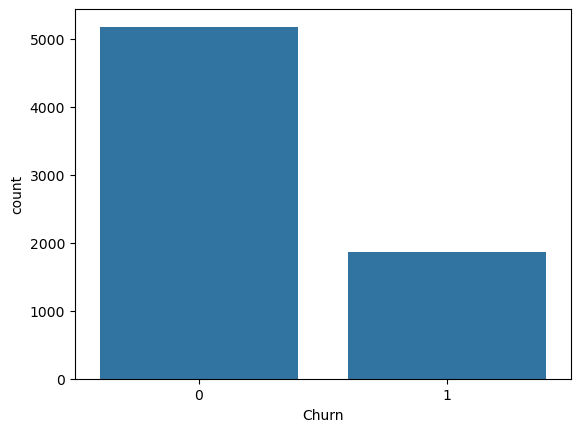

In [69]:
churn_rate =df["Churn"].value_counts(normalize=True) *100
print("Churn Rate:", churn_rate)
sns.countplot(x="Churn", data=df)


Numerical Feature Analysis.

<Axes: xlabel='tenure', ylabel='Count'>

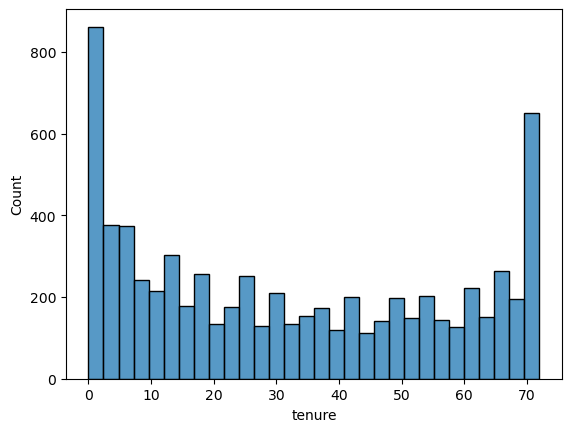

In [59]:
sns.histplot(df["tenure"], bins = 30)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

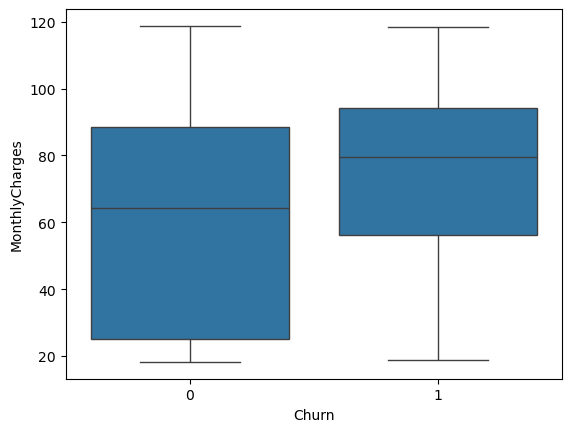

In [60]:
sns.boxplot(data=df, x = "Churn", y="MonthlyCharges")

<Axes: xlabel='Churn', ylabel='TotalCharges'>

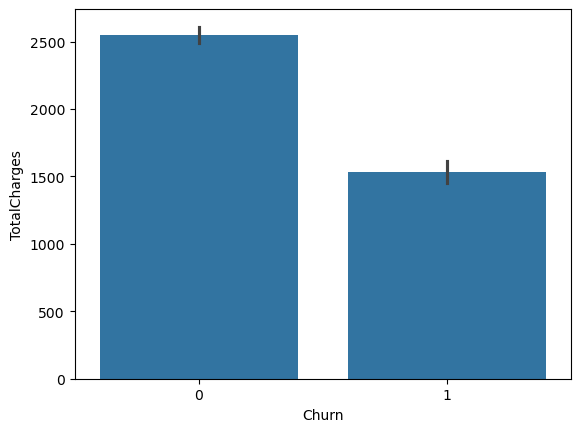

In [61]:
sns.barplot(data=df, x = "Churn", y="TotalCharges")

Categorical Feature Analysis.

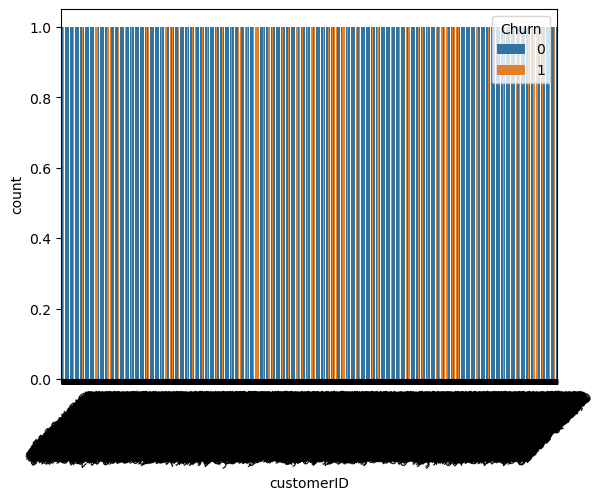

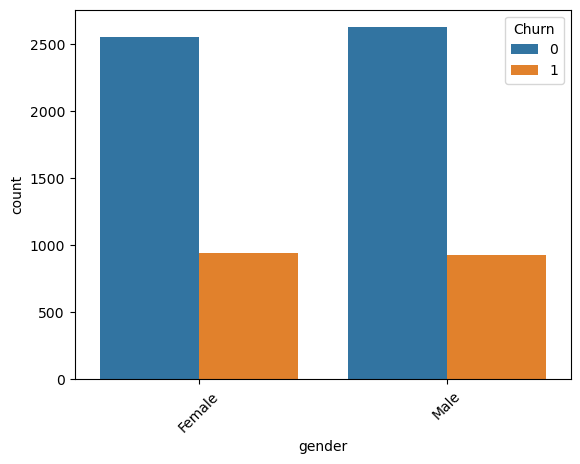

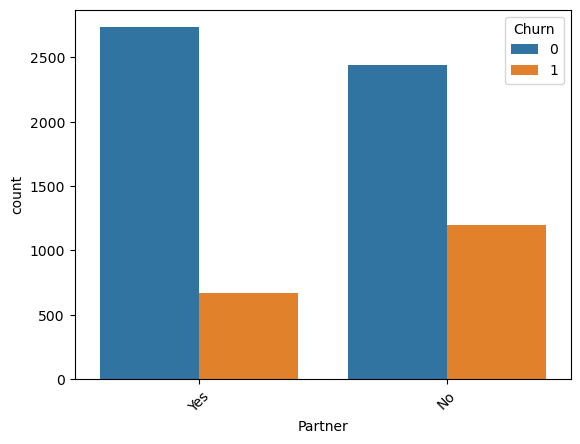

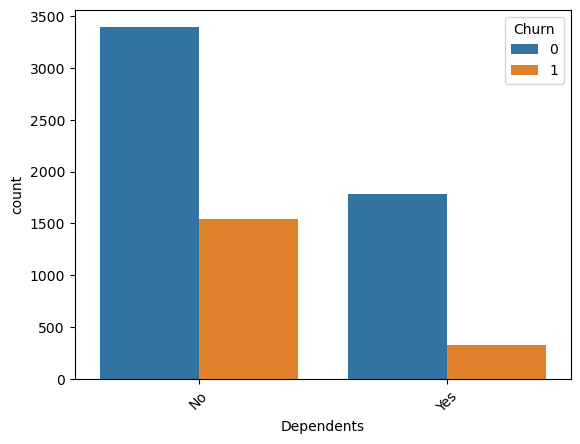

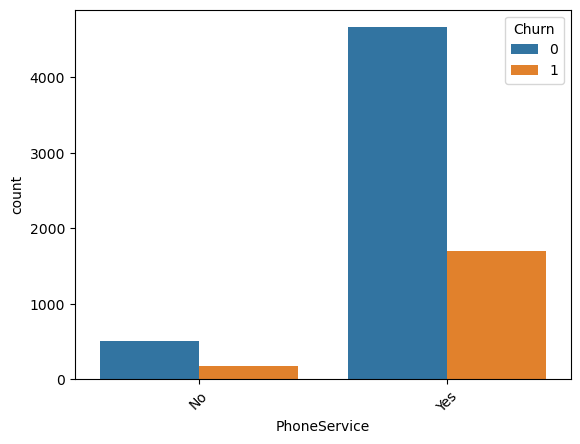

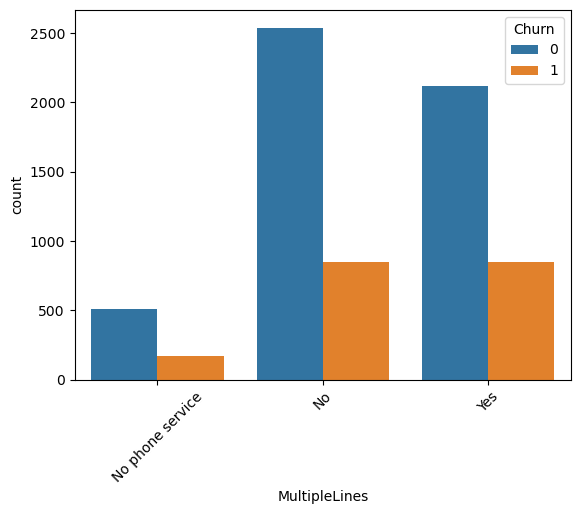

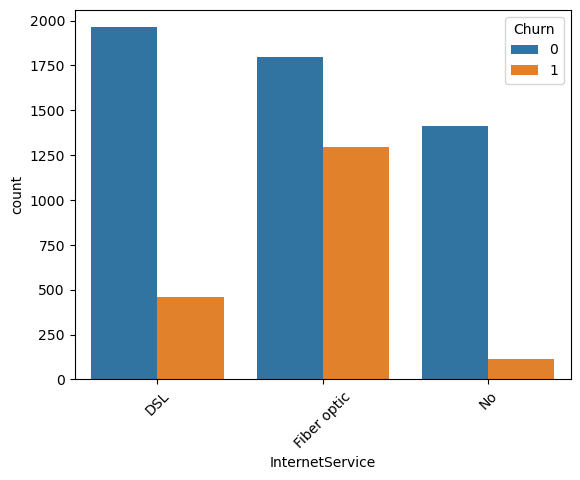

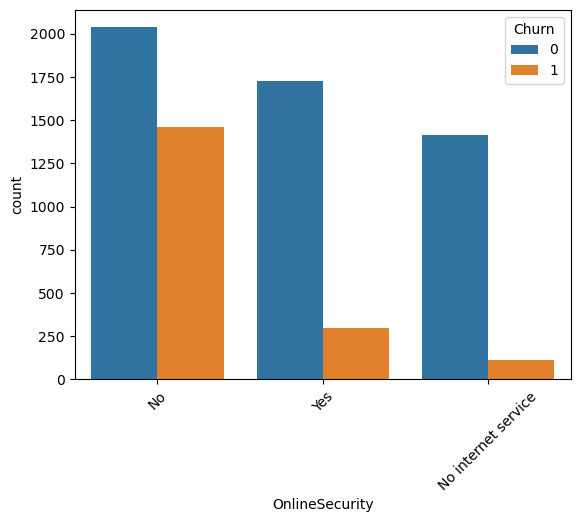

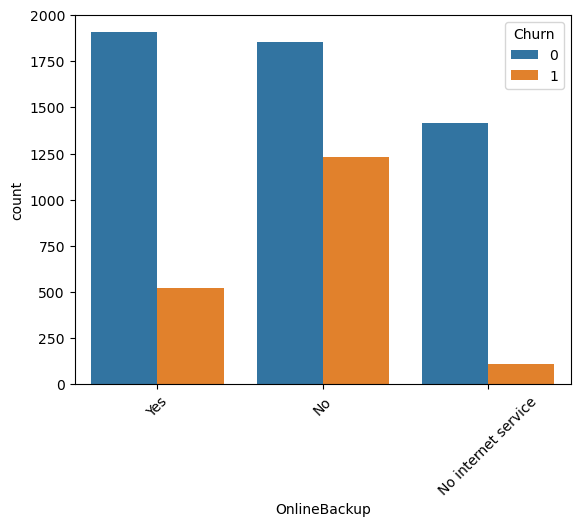

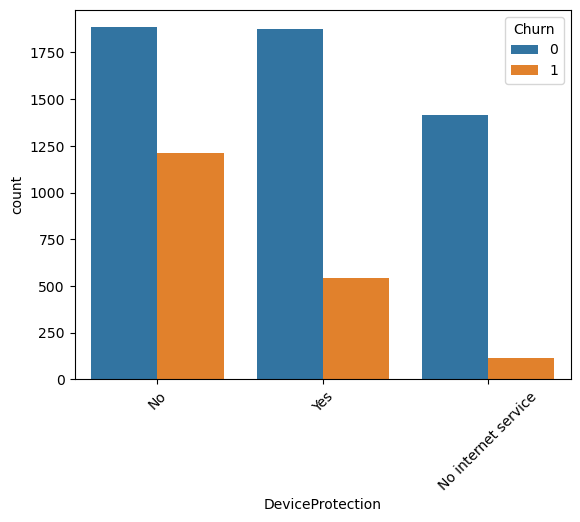

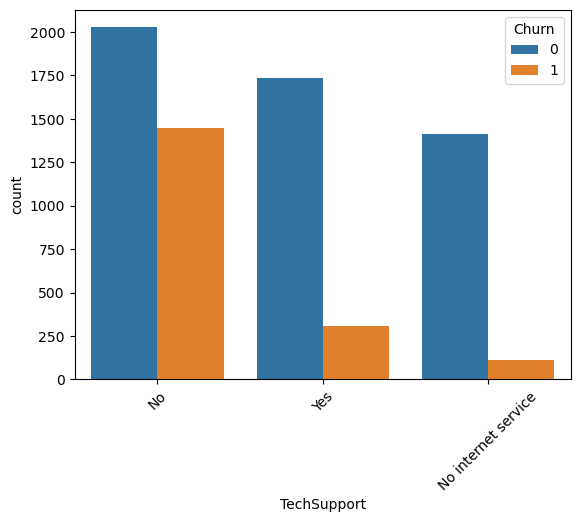

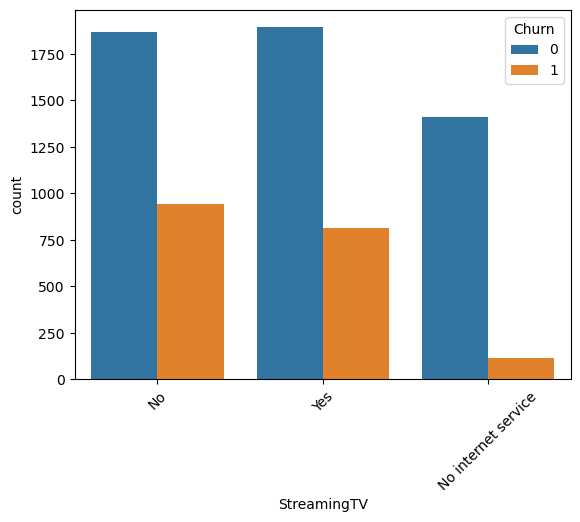

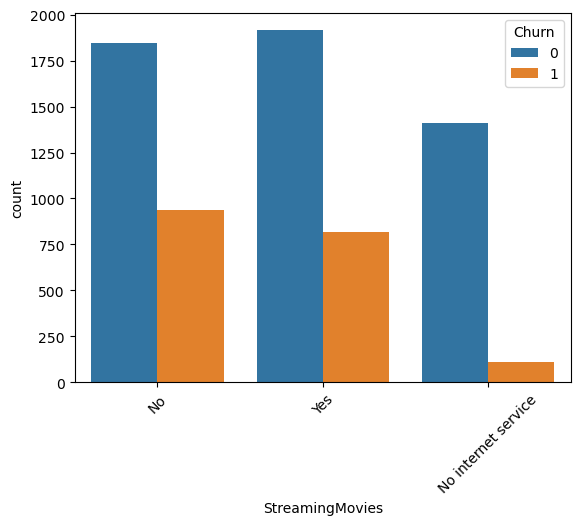

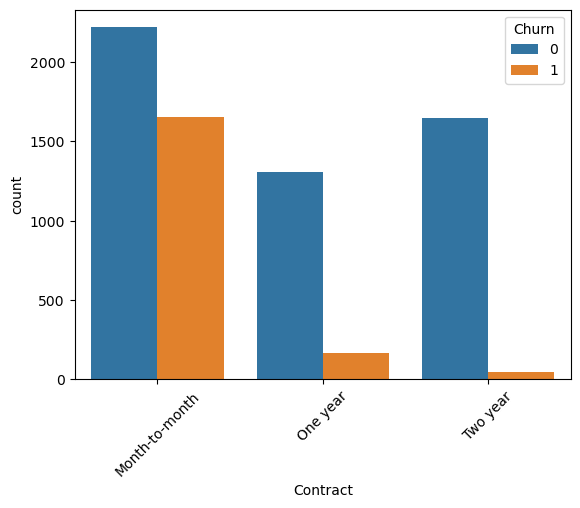

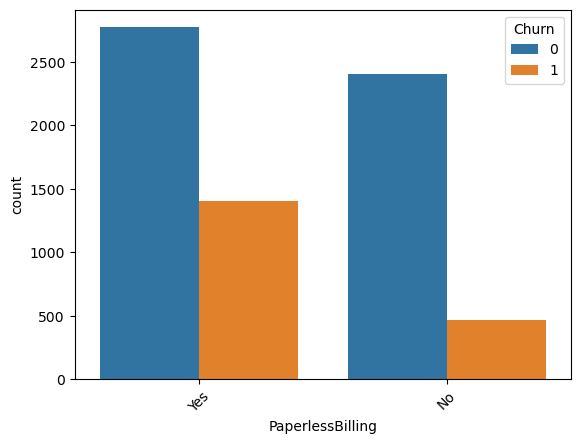

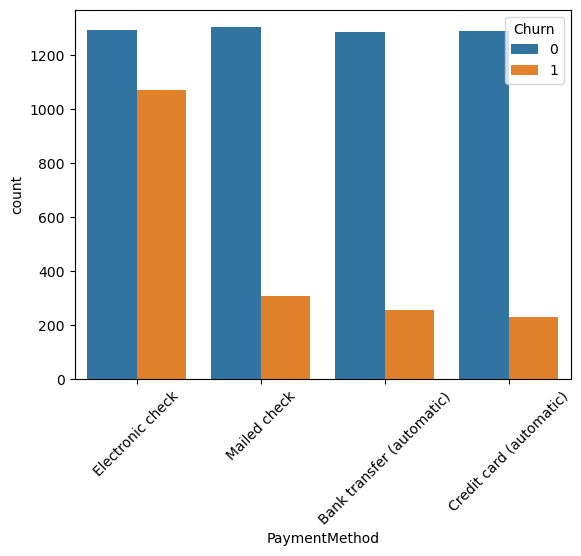

In [62]:
for col in df.select_dtypes(include="object").columns:
    plt.figure()
    sns.countplot(x=col, hue="Churn", data=df)
    plt.xticks(rotation=45)
    plt.show()


Churn Rate by Category.

1. Churn Rate by Contract:

In [63]:
churn_rate_1= df.groupby("Contract")["Churn"].mean()
print("Churn Rate by Contract", churn_rate_1)

Churn Rate by Contract Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


2. Churn Rate by InternetService:

In [64]:
churn_rate_2 = df.groupby("InternetService")["Churn"].mean()
print("Churn Rate by InternetService", churn_rate_2)

Churn Rate by InternetService InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64


3. Churn Rate by PaymentMethod:

In [65]:
churn_rate_3 = df.groupby("PaymentMethod")["Churn"].mean()
print("Churn Rate by PaymentMethod", churn_rate_3)

Churn Rate by PaymentMethod PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64


Visualizing Churn Rate:

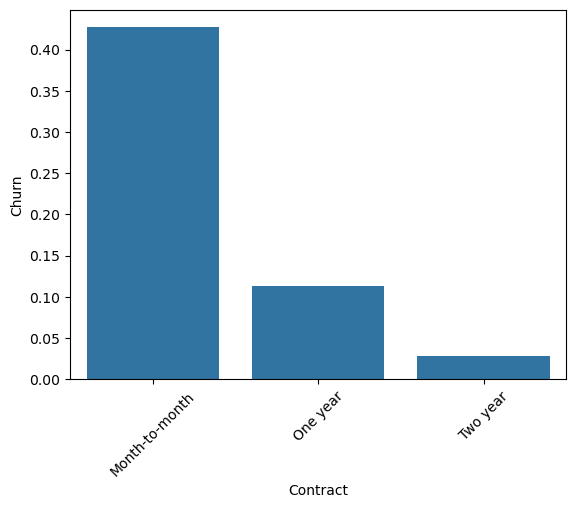

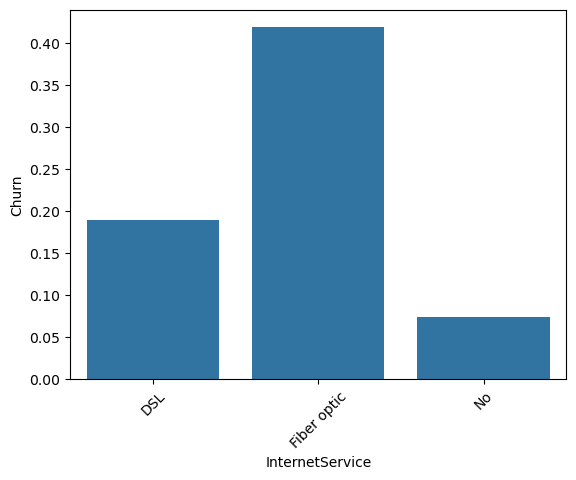

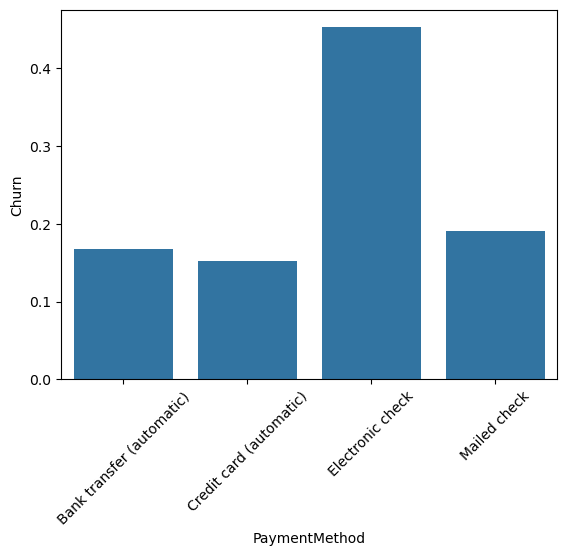

In [66]:
churn_rates = [churn_rate_1, churn_rate_2, churn_rate_3]

for col in churn_rates:
    plt.figure()
    sns.barplot(col)
    plt.xticks(rotation = 45)

Correlation Analysis.

<Axes: >

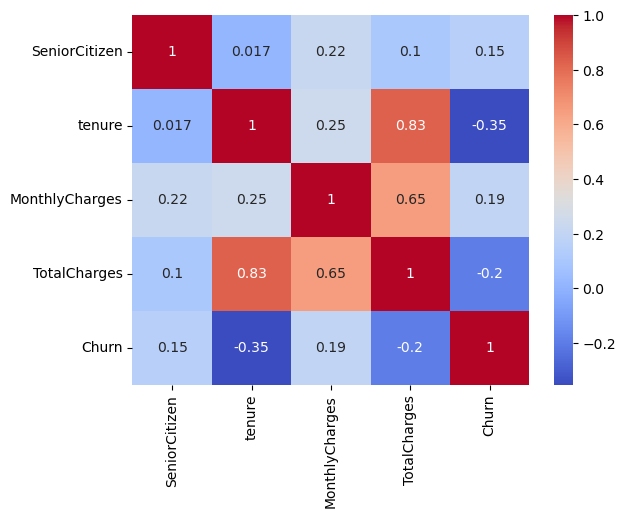

In [67]:
numeric_columns = df.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_columns.corr(), annot=True, cmap = "coolwarm")

Business Insights:

* Month-to-month customers have highest churn rate.

* Low tenure customers churn significantly more.

* High monthly charges correlate with churn.

* Fiber optic users churn more than DSL.



Saving Cleaned Data.

In [68]:
df.to_csv("../data/processed/cleaned.csv")